In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# read csv file using pandas
mall_df = pd.read_csv('M4_data_2021.csv')

In [23]:
mall_df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [24]:
del mall_df['CustomerID']

In [25]:
mall_df.head(5)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [26]:
mall_df.shape

(200, 4)

In [27]:
mall_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [28]:
mall_df['Gender'].replace({'Male':0,'Female':1}, inplace=True)

C:\Users\10414\AppData\Local\Temp\ipykernel_31480\1969126206.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mall_df['Gender'].replace({'Male':0,'Female':1}, inplace=True)
C:\Users\10414\AppData\Local\Temp\ipykernel_31480\1969126206.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mall_df['Ge

In [29]:
mall_df.head(5)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [30]:
mall_df.describe()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,0.560000,38.850000,60.560000,50.200000
std,0.497633,13.969007,26.264721,25.823522
min,0.000000,18.000000,15.000000,1.000000
25%,0.000000,28.750000,41.500000,34.750000
50%,1.000000,36.000000,61.500000,50.000000
75%,1.000000,49.000000,78.000000,73.000000
max,1.000000,70.000000,137.000000,99.000000


In [31]:
mall_df.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [32]:
mall_df.isna().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
standard_scaler = StandardScaler()
mall_scaled_df = pd.DataFrame(standard_scaler.fit_transform(mall_df),
                             columns = mall_df.columns)

In [36]:
mall_scaled_df[0:3]

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913


In [38]:
print(mall_df['Gender'].value_counts()/mall_df.shape[0])

Gender
1    0.56
0    0.44
Name: count, dtype: float64


<Axes: xlabel='Age', ylabel='Annual Income (k$)'>

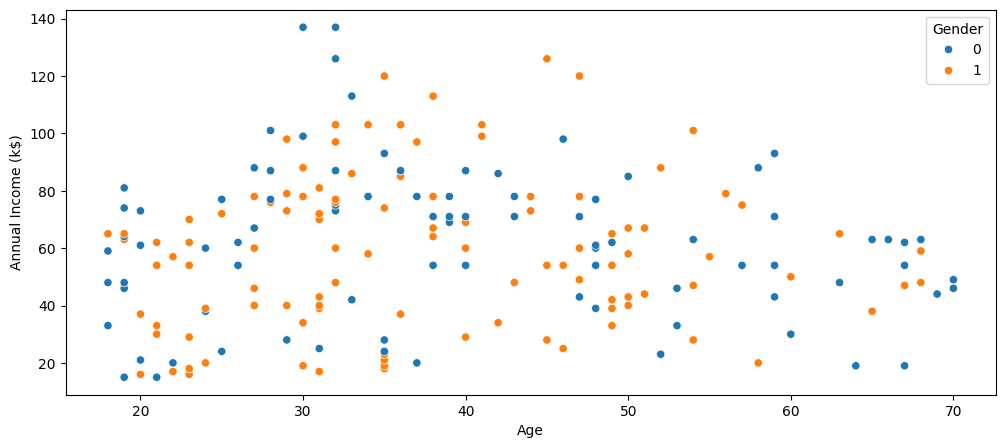

In [43]:
plt.figure(figsize=(12,5))
sns.scatterplot(x='Age', y='Annual Income (k$)', data = mall_df,
               hue = 'Gender')

<Axes: xlabel='Age', ylabel='Annual Income (k$)'>

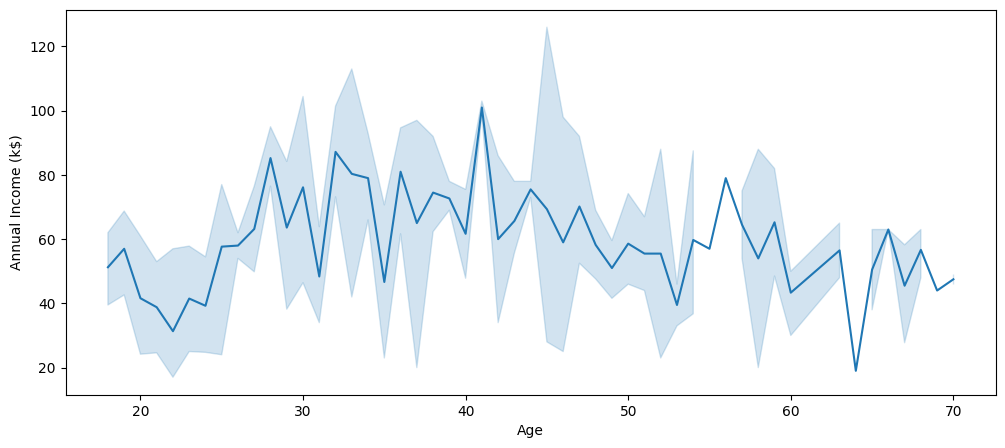

In [44]:
plt.figure(figsize=(12,5))
sns.lineplot(x='Age', y='Annual Income (k$)', data = mall_df)

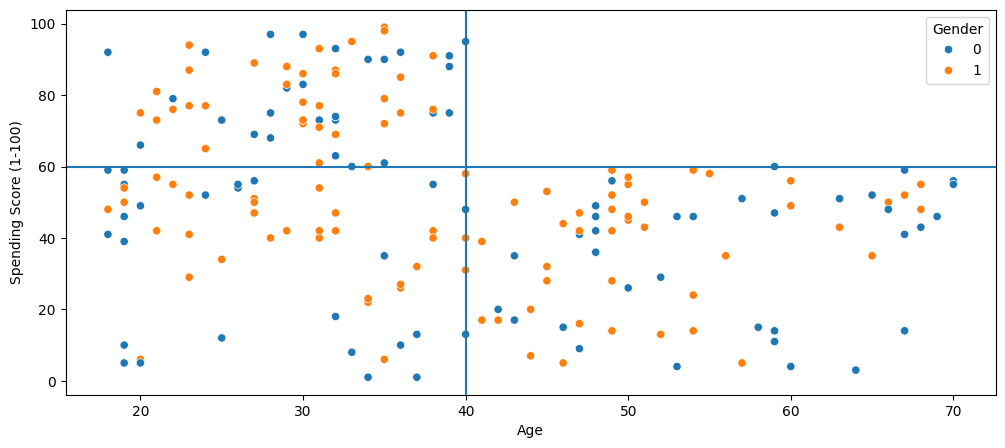

In [47]:
plt.figure(figsize=(12,5))
sns.scatterplot(x='Age', y='Spending Score (1-100)', data = mall_df,
            hue = 'Gender')
plt.axvline(40,0,100)
plt.axhline(60,0,80)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

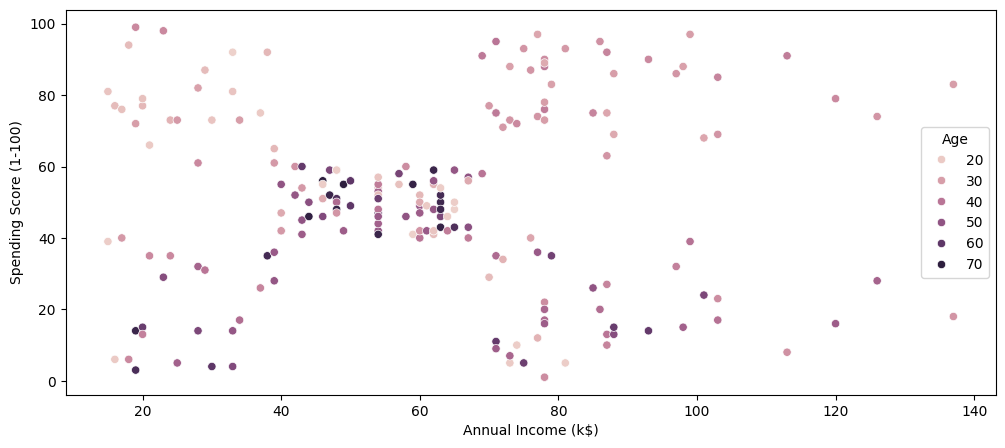

In [48]:
plt.figure(figsize=(12,5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data = mall_df,
            hue = 'Age')

In [49]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [50]:
linkage_list = ['single', 'complete', 'average', 'centroid', 'ward']

In [51]:
data = [mall_df, mall_scaled_df]

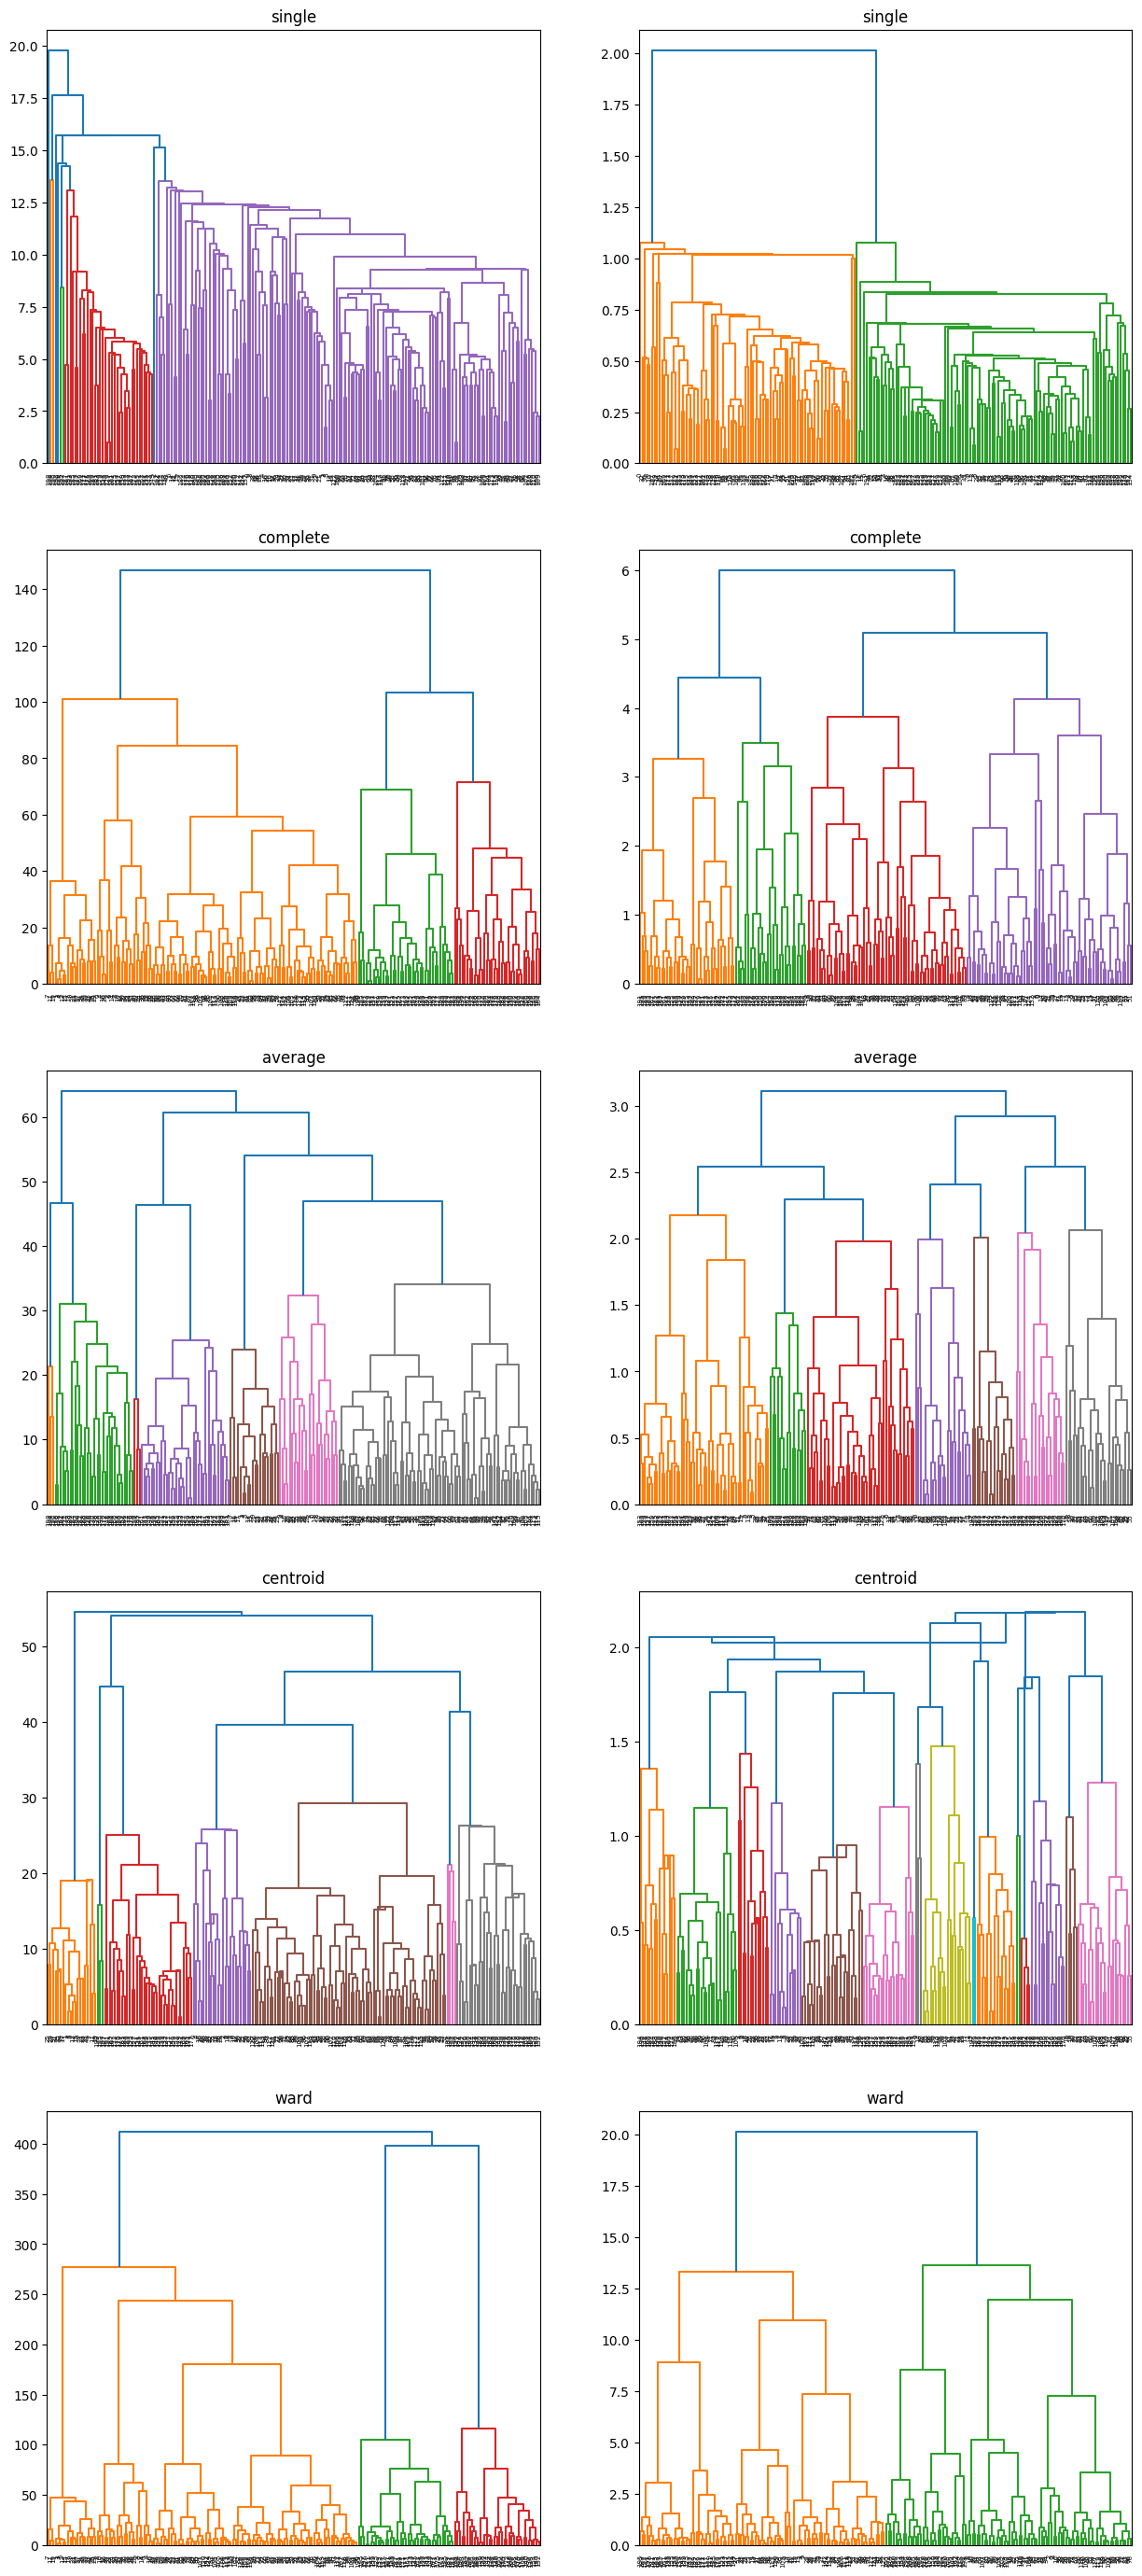

In [57]:
fig, axes = plt.subplots(nrows=len(linkage_list),
                         ncols = 2, figsize = (15,35))
for i in range(len(linkage_list)):
    for j in range(len(data)):
        hierarchical_single = linkage(data[j],
                                      method = linkage_list[i])
        dn = dendrogram(hierarchical_single, ax = axes[i][j])
        axes[i][j].title.set_text(linkage_list[i])
plt.show()

In [58]:
from sklearn.cluster import AgglomerativeClustering

In [59]:
agg_clustering = AgglomerativeClustering(n_clusters = 5,
                                         linkage= 'average')

In [61]:
labels = agg_clustering.fit_predict(mall_df)

In [62]:
mall_df[0:3]

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6


<Axes: xlabel='Age', ylabel='Annual Income (k$)'>

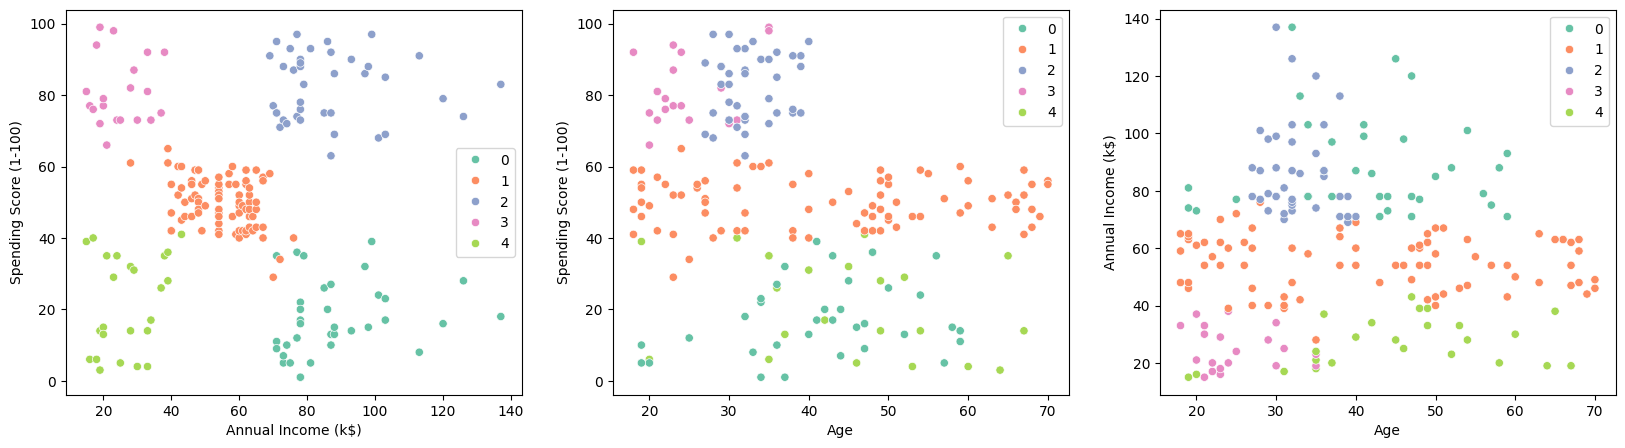

In [67]:
plt.figure(figsize = (20,5))
plt.subplot(131)
sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)',
                data = mall_df,
                hue = labels,
               palette = 'Set2')
plt.subplot(132)
sns.scatterplot(x='Age',
                y='Spending Score (1-100)',
                data = mall_df,
                hue = labels,
               palette = 'Set2')
plt.subplot(133)
sns.scatterplot(x='Age',
                y='Annual Income (k$)',
                data = mall_df,
                hue = labels,
               palette = 'Set2')